# METAR comparison to reanalysis products 

This notebook is set up to compare METAR to reanalysis products. The comparison is done with time series for a particular location first, then map-based comparisons for time periods. 

This notebook is set up to compare METAR with [AORC](https://registry.opendata.aws/noaa-nws-aorc/) data, a reanalysis product produced by NOAA for the continental U.S. and Alaska from 1979-2023. 

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import s3fs

from datetime import datetime, timedelta

import metpy.calc as mpcalc
from metpy.units import units

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

### Time series comparison 

Get the METAR data from [Dynamical](https://dynamical.org/). Choose a location and a time range. 

In [13]:
def valid_date(date): 
    '''
    Helper function to check that the date range is valid for METAR and AORC.
    '''
    assert isinstance(date, datetime)
    assert date >= datetime(1979, 1, 1, 0), 'Date cannot be earlier than 1979' 
    assert date < datetime(2024, 1, 1, 0), 'Date cannot be more recent than 2023' 
    return date

In [109]:
target = (39.8328, -104.6575)
target_code = 'DEN'
# TODO add "find_closest_metar" functionality, bounding box search, etc. 

time_start = valid_date(datetime(2019, 1, 1, 0))
time_end = valid_date(datetime(2022, 12, 31, 23))

target_vars = ['tmpc', 'relh', 'drct', 'sknt']

In [110]:
metar_base = "https://data.source.coop/dynamical/asos-parquet"
metar_urls = [f"{metar_base}/year={y}/data.parquet" for y in range(time_start.year, time_end.year + 1)]
metar_urls

['https://data.source.coop/dynamical/asos-parquet/year=2019/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2020/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2021/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2022/data.parquet']

In [111]:
df = duckdb.execute(f"""
    SELECT valid, longitude, latitude, station, name, country, {', '.join(target_vars)}
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2
    ORDER BY valid
""", [metar_urls, target_code]).fetchdf()

In [106]:
df = duckdb.execute(f"""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2
    ORDER BY valid
""", [metar_urls[1], target_code]).fetchdf()

In [112]:
df.columns

Index(['valid', 'longitude', 'latitude', 'station', 'name', 'country', 'tmpc',
       'relh', 'drct', 'sknt'],
      dtype='object')

In [113]:
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.longitude,df.latitude))
gdf

,valid,longitude,latitude,station,name,country,tmpc,relh,drct,sknt,geometry
0,2019-01-01 00:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-13.89,86.80,350.0,11.0,POINT (-104.6575 39.8328)
1,2019-01-01 01:25:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-13.28,82.58,360.0,8.0,POINT (-104.6575 39.8328)
2,2019-01-01 01:51:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-13.00,78.18,350.0,11.0,POINT (-104.6575 39.8328)
3,2019-01-01 01:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-13.28,82.58,350.0,10.0,POINT (-104.6575 39.8328)
4,2019-01-01 02:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-13.89,86.80,340.0,12.0,POINT (-104.6575 39.8328)
...,...,...,...,...,...,...,...,...,...,...,...
38973,2022-12-31 19:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,3.33,72.93,30.0,4.0,POINT (-104.6575 39.8328)
38974,2022-12-31 20:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,3.89,69.85,90.0,3.0,POINT (-104.6575 39.8328)
38975,2022-12-31 21:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,3.89,72.45,150.0,4.0,POINT (-104.6575 39.8328)
38976,2022-12-31 22:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,2.78,72.24,50.0,9.0,POINT (-104.6575 39.8328)


Get the AORC data for the target time and location 

In [123]:
col_refs = {
    'tmpc': 'Temperature (degC)', 
    'relh': 'Relative Humidity (%)',
    'drct': 'Wind Direction (deg)',
    'sknt': 'Wind Speed (knots)',
}

def aorc_to_metar_cols(df_aorc): 
    '''
    '''
    for col in target_vars: 
        if col == 'tmpc' : 
            print('Converting TMP_2maboveground in K to tmpc in C') 
            # df_aorc.rename('TMP_2maboveground', 'tmpc') 
            df_aorc['tmpc'] = df_aorc['TMP_2maboveground'] - 273
        if col == 'relh' : 
            print('Converting SPFH_2maboveground to relh (%)') 
            q = df_aorc['SPFH_2maboveground']
            tmp = df_aorc['tmpc']
            prs = df_aorc['PRES_surface']
            df_aorc['relh'] = spech_to_relh(q, tmp, prs)
        if col == 'drct' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)') 
            dir_rad = np.arctan2(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            dir_deg = np.degrees(dir_rad) + 180.0
            
            # Ensure all angles fall strictly between 0 and 360 degrees (e.g., handles negative angles smoothly)
            df_aorc['drct'] = np.mod(dir_deg, 360.0)  
        if col == 'sknt' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)') 
            speed_mps = np.hypot(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            df_aorc['sknt'] = speed_mps * 1.94384
            
            
            # df_aorc['relh'] = (tmp.dims, rh_vals)
        
    return df_aorc

def spech_to_relh(q, tmp, prs): 
    p_hpa = prs / 100.0

    # 3. Step-by-step vectorized calculation
    # Calculate mixing ratio (w)
    w = q / (1.0 - q)
    
    # Calculate saturation vapor pressure (es) in hPa via Bolton (1980)
    es = 6.112 * np.exp((17.67 * tmp) / (tmp + 243.5))
    
    # Calculate saturation mixing ratio (ws)
    epsilon = 0.62198
    ws = epsilon * es / (p_hpa - es)
    
    # Calculate Relative Humidity (%) bounded logically between 0% and 100%
    rh_array = (w / ws) * 100.0
    rh_array = np.clip(rh_array, 0.0, 100.0)
    return rh_array

In [20]:
aorc_base = "noaa-nws-aorc-v1-1-1km" 
aorc_urls = [f"s3://{aorc_base}/{y}.zarr" for y in range(time_start.year, time_end.year + 1)]
aorc_urls

['s3://noaa-nws-aorc-v1-1-1km/2019.zarr',
 's3://noaa-nws-aorc-v1-1-1km/2020.zarr',
 's3://noaa-nws-aorc-v1-1-1km/2021.zarr',
 's3://noaa-nws-aorc-v1-1-1km/2022.zarr']

In [38]:
s3_out = s3fs.S3FileSystem(anon=True)
fileset_aorc = [
    s3fs.S3Map(root=url, s3=s3_out, check=False)
    for url in aorc_urls
]

df_aorc = xr.open_mfdataset(fileset_aorc, engine='zarr')

In [39]:
df_aorc = df_aorc.rename({'latitude': 'y', 'longitude': 'x'})
df_aorc

<xarray.Dataset> Size: 79TB
Dimensions:              (time: 35064, y: 4201, x: 8401)
Coordinates:
  * y                    (y) float64 34kB 20.0 20.01 20.02 ... 54.98 54.99 55.0
  * x                    (x) float64 67kB -130.0 -130.0 -130.0 ... -60.01 -60.0
  * time                 (time) datetime64[ns] 281kB 2019-01-01 ... 2022-12-3...
Data variables:
    APCP_surface         (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DLWRF_surface        (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DSWRF_surface        (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    PRES_surface         (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    SPFH_2maboveground   (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    TMP_2maboveground    (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    UGRD_10maboveground  (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    VGRD_10maboveground  (time, y, x) float64 10TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>

In [50]:
# find the nearest point in the AORC grid 
lat_idx = np.abs(df_aorc.y.values - target[0]).argmin()
lon_idx = np.abs(df_aorc.x.values - target[1]).argmin()

In [103]:
# select the target point and target time range 
df_aorc_pt = df_aorc.isel(y=lat_idx, x=lon_idx)
df_aorc_pt = df_aorc_pt.sel(time=slice(time_start, time_end))
del df_aorc # save space 

In [120]:
df_aorc_pt = aorc_to_metar_cols(df_aorc_pt)

Converting TMP_2maboveground in K to tmpc in C
Converting SPFH_2maboveground to relh (%)
Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)
Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)


In [121]:
df_aorc_pt

<xarray.Dataset> Size: 4MB
Dimensions:              (time: 35064)
Coordinates:
    y                    float64 8B 39.83
    x                    float64 8B -104.7
  * time                 (time) datetime64[ns] 281kB 2019-01-01 ... 2022-12-3...
Data variables:
    APCP_surface         (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    DLWRF_surface        (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    DSWRF_surface        (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    PRES_surface         (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    SPFH_2maboveground   (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    TMP_2maboveground    (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    UGRD_10maboveground  (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    VGRD_10maboveground  (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    tmpc                 (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    relh                 (time) float64 281kB 85.37 83.35 80.74 ... 48.92 54.31
    sknt                 (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>
    drct                 (time) float64 281kB dask.array<chunksize=(144,), meta=np.ndarray>

KeyError: 'drct'

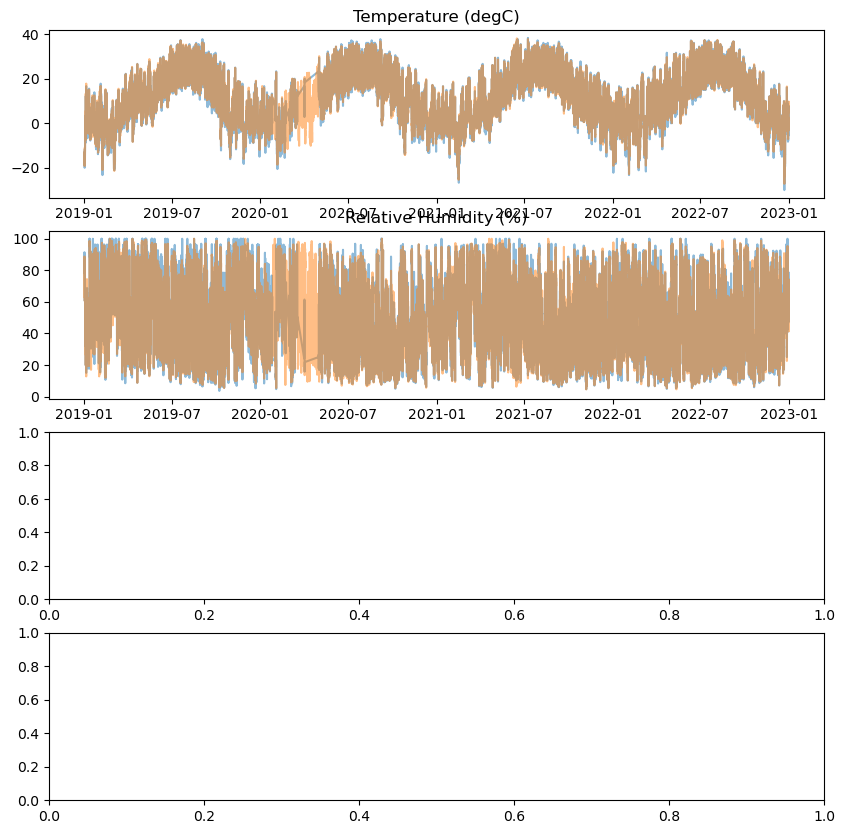

In [122]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(3 * len(target_vars), 10)) 

for i, v in enumerate(target_vars): 
    axes[i].set_title(col_refs[v])
    axes[i].plot(gdf['valid'], gdf[v], alpha=0.5) 

    axes[i].plot(df_aorc_pt['time'], df_aorc_pt[v], alpha=0.5)

plt.tight_layout()
plt.show()